# RL - Chapter 7 - N-step TD - Windy Gridworld

Applies n-step TD and SARSA methods to the Windy Gridworld to study multi-step returns.

Includes:

- Sarsa


In [19]:
# generate the table of contents
from scripts.toc import generate_toc

path = 'ch_7_ns_TD_p2_windy_gridworld.ipynb'
generate_toc(path)

## Table of Contents

- [RL - Chapter 7 - N-step TD - Windy Gridworld](#rl-chapter-7-n-step-td-windy-gridworld)
  - [Windy Gridworld environment](#windy-gridworld-environment)
  - [Run n step TD methods](#run-n-step-td-methods)
  - [Final Path](#final-path)

In [20]:
# import libraries and configure the notebook
import numpy as np
import matplotlib.pyplot as plt
from scripts.nstep_td import NstepTDHyperparameters, NstepTDOnPolicy, NstepTDOffPolicy, NstepTDOffPolicyRecursive, NstepTDTreeBackup, NstepTDQSigma

# set decimal precision for numpy arrays
np.set_printoptions(precision=1, suppress=True)

## Windy Gridworld environment


In [21]:
# Windy Gridworld environment
class WindyGridworld:
    def __init__(self):
        self.y_max = 7
        self.x_max = 10
        self.start_state = (0, 3)
        self.goal_state = (7, 3)
        # wind strength for each column
        self.wind = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
        # self.wind = [0, 0, 0, 1, 1, 1, 2, 2, 1, 0]
        # action space: up, down, left, right
        actions = [(x, y) for x in range(-1, 2) for y in range(-1, 2) if abs(x) + abs(y) != 0]
        # actions = [(0, 1), (0, -1), (-1, 0), (1, 0)]
        self.actions = actions
        # self.actions = [(0, 1), (0, -1), (-1, 0), (1, 0)]
        self.n_actions = len(self.actions)

## Run n step TD methods


In [22]:
# set the n-step control parameters
params = NstepTDHyperparameters(n=5, alpha=0.1, gamma=1.0, behavior_epsilon=0.1, n_episodes=600, excepted_sarsa=True)

# create the environment
env = WindyGridworld()

In [23]:
# run On Policy N step Sarsa
sarsa_on_policy = NstepTDOnPolicy(env, params)
sarsa_on_policy.run()

In [24]:
# run Off Policy N step Sarsa
sarsa_off_policy = NstepTDOffPolicy(env, params)
sarsa_off_policy.run()

In [25]:
# run recursive N step Sarsa
sarsa_recursive = NstepTDOffPolicyRecursive(env, params)
sarsa_recursive.run()

In [26]:
# run tree backup
tree_backup = NstepTDTreeBackup(env, params)
tree_backup.run()

In [27]:
# run NstepTDQSigma
nstep_td_qsigma = NstepTDQSigma(env, params)
nstep_td_qsigma.run()

## Final Path


In [28]:
# find path from start to goal using learned policy
def find_path(env: WindyGridworld, Q):
    state = env.start_state
    path = [state]
    while state != env.goal_state:
        action = np.argmax(Q[state])
        dx, dy = env.actions[action]
        x, y = state
        wind_strength = env.wind[x]
        x += dx
        y += dy
        y += wind_strength
        # keep within grid boundaries
        x = max(0, min(env.x_max - 1, x))
        y = max(0, min(env.y_max - 1, y))
        state = (x, y)
        path.append(state)
        if len(path) > 100:
            print("Policy did not reach goal within 100 steps.")
            break
    return path

In [29]:
# find path on policy
path_on_policy = find_path(env, sarsa_on_policy.Q)

In [30]:
# find path off policy
path_off_policy = find_path(env, sarsa_off_policy.Q)

In [31]:
# find path recursive
path_recursive = find_path(env, sarsa_recursive.Q)

In [32]:
# find path tree backup
path_tree_backup = find_path(env, tree_backup.Q)

In [33]:
# find path NstepTDQSigma
path_qsigma = find_path(env, nstep_td_qsigma.Q)

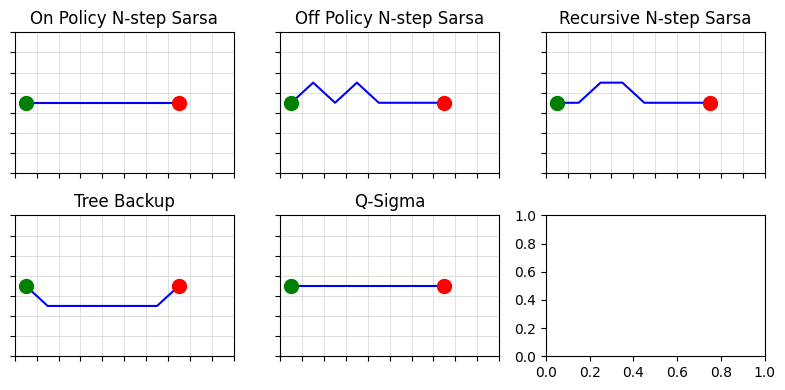

In [34]:
# plot the n-step control results

def plot_result(ax, title, path):
    ax.set_title(title)
    ax.set_xlim(-0.5, env.x_max - 0.5)
    ax.set_ylim(-0.5, env.y_max - 0.5)
    ax.set_xticks(np.arange(-0.5, env.x_max, 1))
    ax.set_yticks(np.arange(-0.5, env.y_max, 1))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(True, which='both', color='lightgray', linewidth=0.5)
    ax.plot([s[0] for s in path], [s[1] for s in path], 'b-', label='Path')
    ax.plot(env.start_state[0], env.start_state[1], 'go', markersize=10, label='Start')
    ax.plot(env.goal_state[0], env.goal_state[1], 'ro', markersize=10, label='Goal')


# plot grid
fig, axs = plt.subplots(2, 3, figsize=(8, 4))
plot_result(axs[0, 0], "On Policy N-step Sarsa", path_on_policy)
plot_result(axs[0, 1], "Off Policy N-step Sarsa", path_off_policy)
plot_result(axs[0, 2], "Recursive N-step Sarsa", path_recursive)
plot_result(axs[1, 0], "Tree Backup", path_tree_backup)
plot_result(axs[1, 1], "Q-Sigma", path_qsigma)
plt.tight_layout()
plt.show()

In [35]:
# # plot number of steps per episode
# plt.figure(figsize=(6, 4))
# plt.plot(sarsa_on_policy.n_steps_per_episode, label='On Policy')
# plt.plot(sarsa_off_policy.n_steps_per_episode, label='Off Policy')
# plt.plot(sarsa_recursive.n_steps_per_episode, label='Recursive')
# plt.ylim(0, 500)
# plt.xlabel('Episode')
# plt.ylabel('Number of Steps')
# plt.title('Number of Steps per Episode in Sarsa on Windy Gridworld')
# plt.grid()
# plt.legend()
# plt.show()